In [24]:
# DI193 Hackathon 1: Project 2 -- AI-Generated Fitness Tracker

# Step 1. "Create User Profiles: Simulate user data"
# Instead of creating user profiles and data, I am using the Health and fitness dataset (health_fitness_dataset) posted by Kaggle user Evan.
# According to its Kaggle page, this dataset records the real health and fitness tracking data of 3,000 participants. However, the page doesn't detail much about the collection of the data and I suspect it may be synthetic. Either way, the dataset is useful for this project. It has most of the requested data features and is large enough to make analysis interesting.
# Dataset Source: https://www.kaggle.com/datasets/evan65549/health-and-fitness-dataset

# Loading libraries and doing initial EDA and data cleaning:

import pandas as pd
import numpy as np
import scipy.stats as stats

df_raw = pd.read_csv('evan_fitness.csv')
df = df_raw.copy()
df.head(10)

,participant_id,date,age,gender,height_cm,weight_kg,bmi,activity_type,duration_minutes,intensity,...,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,endurance_level,sleep_hours,stress_level,hydration_level,smoking_status,health_condition,fitness_level
0,1,2024/1/1,56,F,165.3,50.55,18.50,Dancing,42.1,Low,...,69.5,110.7,72.9,5.37,6.6,4,1.5,Never,NaN,0.04
1,1,2024/1/4,56,F,165.3,55.38,20.27,Swimming,66.9,Low,...,69.5,110.7,72.9,5.39,8.1,3,1.8,Never,NaN,0.07
2,1,2024/1/5,56,F,165.3,56.49,20.68,Swimming,20.0,Medium,...,69.5,110.7,72.9,5.42,6.2,5,2.7,Never,NaN,0.09
3,1,2024/1/7,56,F,165.3,52.23,19.12,Weight Training,23.5,Medium,...,69.5,110.7,72.9,5.44,7.2,4,2.6,Never,NaN,0.21
4,1,2024/1/9,56,F,165.3,53.96,19.75,Swimming,75.0,Medium,...,69.5,110.7,72.9,5.47,7.1,7,1.5,Never,NaN,0.33
5,1,2024/1/10,56,F,165.3,55.56,20.33,HIIT,86.5,Medium,...,69.5,110.7,72.9,5.49,7.5,8,2.2,Never,NaN,0.37
6,1,2024/1/11,56,F,165.3,53.89,19.72,Weight Training,24.4,High,...,69.5,110.7,72.9,5.52,6.6,7,2.8,Never,NaN,0.51
7,1,2024/1/12,56,F,165.3,55.91,20.46,HIIT,20.0,Low,...,69.5,110.7,72.9,5.55,6.1,4,1.6,Never,NaN,0.58
8,1,2024/1/17,56,F,165.3,57.47,21.03,HIIT,20.0,Medium,...,69.5,110.7,72.9,5.57,7.2,5,3.3,Never,NaN,0.68
9,1,2024/1/18,56,F,165.3,54.29,19.87,Weight Training,20.0,Medium,...,69.5,110.7,72.9,5.60,5.6,9,2.0,Never,NaN,0.82


In [25]:
df.shape

(687701, 23)

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 687701 entries, 0 to 687700
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   participant_id            687701 non-null  int64  
 1   date                      687701 non-null  str    
 2   age                       687701 non-null  int64  
 3   gender                    687701 non-null  str    
 4   height_cm                 687701 non-null  float64
 5   weight_kg                 687701 non-null  float64
 6   bmi                       687701 non-null  float64
 7   activity_type             687701 non-null  str    
 8   duration_minutes          687701 non-null  float64
 9   intensity                 687701 non-null  str    
 10  calories_burned           687701 non-null  float64
 11  daily_steps               687701 non-null  int64  
 12  avg_heart_rate            687701 non-null  int64  
 13  resting_heart_rate        687701 non-null  float64
 14 

In [27]:
df.describe()

,participant_id,age,height_cm,weight_kg,bmi,duration_minutes,calories_burned,daily_steps,avg_heart_rate,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,endurance_level,sleep_hours,stress_level,hydration_level,fitness_level
count,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000
mean,1499.781828,41.658602,168.587699,61.728155,21.663562,74.026662,15.381302,8628.370918,131.454165,70.010547,120.001260,80.188079,9.492198,7.048799,5.472029,2.499427,9.524900
std,865.997215,13.581770,9.140811,8.547730,1.939251,35.095472,9.985552,2054.756608,17.814744,5.074563,10.008917,8.239418,2.246180,0.972068,1.914969,0.579050,5.502485
min,1.000000,18.000000,145.000000,39.760000,18.500000,20.000000,0.800000,-419.000000,82.000000,51.100000,78.000000,53.700000,4.530000,4.000000,1.000000,1.500000,0.020000
25%,749.000000,30.000000,161.700000,55.500000,20.060000,46.300000,7.800000,7203.000000,118.000000,66.500000,113.100000,74.600000,7.820000,6.400000,4.000000,2.000000,4.770000
50%,1499.000000,42.000000,168.200000,61.060000,21.640000,72.800000,13.000000,8607.000000,130.000000,70.000000,120.200000,80.100000,9.460000,7.000000,5.000000,2.500000,9.510000
75%,2249.000000,53.000000,175.300000,67.310000,23.270000,99.500000,20.700000,10027.000000,144.000000,73.500000,127.000000,85.700000,11.050000,7.700000,7.000000,3.000000,14.230000
max,3000.000000,64.000000,198.500000,98.110000,24.900000,152.100000,92.000000,17241.000000,206.000000,87.100000,152.700000,112.100000,18.840000,10.000000,10.000000,3.500000,21.930000


In [28]:
df.isna().sum()

participant_id                   0
date                             0
age                              0
gender                           0
height_cm                        0
weight_kg                        0
bmi                              0
activity_type                    0
duration_minutes                 0
intensity                        0
calories_burned                  0
daily_steps                      0
avg_heart_rate                   0
resting_heart_rate               0
blood_pressure_systolic          0
blood_pressure_diastolic         0
endurance_level                  0
sleep_hours                      0
stress_level                     0
hydration_level                  0
smoking_status                   0
health_condition            490275
fitness_level                    0
dtype: int64

In [48]:
# We can see that there are no missing values along all columns except for health_condition, which is missing many values. What percentage?
print(df['health_condition'].isna().mean())

0.7129188411824324


In [52]:
# Because this is over 50%, I will just drop the health_condition column.
df = df.dropna(axis=1)
df.isna().sum()

participant_id              0
date                        0
age                         0
gender                      0
height_cm                   0
weight_kg                   0
bmi                         0
activity_type               0
duration_minutes            0
intensity                   0
calories_burned             0
daily_steps                 0
avg_heart_rate              0
resting_heart_rate          0
blood_pressure_systolic     0
blood_pressure_diastolic    0
endurance_level             0
sleep_hours                 0
stress_level                0
hydration_level             0
smoking_status              0
fitness_level               0
dtype: int64

In [ ]:
# Now we can see we have no missing values.

In [30]:
# Step 2. "Generating Personalized Workouts:
# Instructions:
# Use conditionals and functions to generate daily workout plans based on:
#     Fitness goals (e.g., strength vs. cardio).
#     Past activity trends (e.g., low activity suggests lighter workouts).
# Simulate recommendations like: “Based on your activity, try a 30-min HIIT session today.”"

# This dataset does not have fitness goals data so instead I will simply use past activity trends to generate daily workout plans.
# These include data such as history of past workout types, duration, and intensity.

# First let's see a list of all the types of workouts performed by users in this dataset:

workout_types = df['activity_type'].unique()
workout_types

<StringArray>
[        'Dancing',        'Swimming', 'Weight Training',            'HIIT',
         'Running',         'Walking',          'Tennis',      'Basketball',
            'Yoga',         'Cycling']
Length: 10, dtype: str

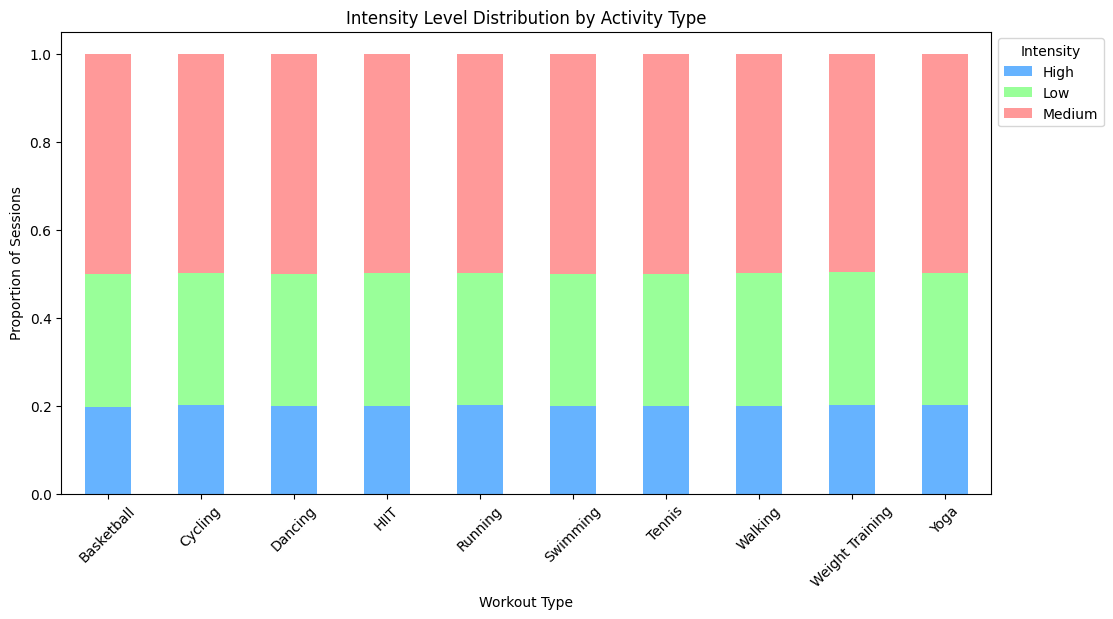

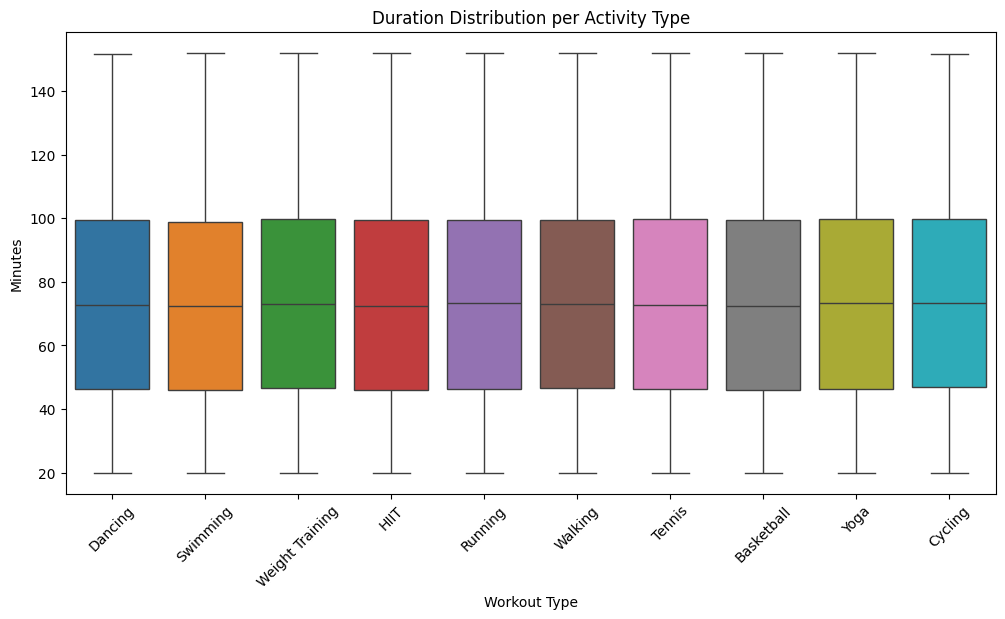

In [31]:
# The recommendation engine will be based on past workout types, duration, and intensity. Let's first see if duration and intensity are distinct for different workout types:

import matplotlib.pyplot as plt
import seaborn as sns


# Analyze Intensity Variety
# Create a cross-tabulation of activity type and intensity
intensity_dist = pd.crosstab(df['activity_type'], df['intensity'], normalize='index')

# Plotting the Intensity Distribution
intensity_dist.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#66b3ff','#99ff99','#ff9999'])
plt.title('Intensity Level Distribution by Activity Type')
plt.xlabel('Workout Type')
plt.ylabel('Proportion of Sessions')
plt.legend(title='Intensity', loc='upper left', bbox_to_anchor=(1, 1))
plt.xticks(rotation=45)
plt.show()

# Analyze Duration Trends
plt.figure(figsize=(12, 6))
sns.boxplot(x='activity_type', y='duration_minutes', data=df, hue='activity_type', legend=False)
plt.title('Duration Distribution per Activity Type')
plt.xlabel('Workout Type')
plt.ylabel('Minutes')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# In this case we see that duration and intensity are equally distributed among all activity types.
# Because a given activity type does not imply any duration or intensity, recommendations will
# be based on duration, intensity, and activity type for each user.

# Core Recommendation Engine:

class UserProfile:
    def __init__(self, participant_id, dataframe):
        self.__participant_id = participant_id
        self.__history = dataframe[dataframe['participant_id'] == participant_id]

    def get_trends(self):
        if self.__history.empty:
            return None
        return {
            'id': self.__participant_id,
            'avg_duration': self.__history['duration_minutes'].mean(),
            'fav_activity': self.__history['activity_type'].mode()[0],
            'pref_intensity': self.__history['intensity'].mode()[0],
            'total_sessions': len(self.__history)
        }

class Recommender:
    """Base class with a shared utility for rounding (Inheritance)."""
    
    def _round_to_five(self, minutes):
        """Helper method to ensure user-friendly durations."""
        return 5 * round(minutes / 5)

    def generate(self, trends):
        raise NotImplementedError("Subclasses must implement generate()")

class DailyPlan(Recommender):
    """Provides a smoothed recommendation based on history."""
    def generate(self, trends):
        # Using the inherited rounding helper
        raw_dur = trends['avg_duration']
        clean_dur = self._round_to_five(raw_dur)
        
        act = trends['fav_activity']
        lvl = trends['pref_intensity']
        return f"User {trends['id']}: Based on your trend, try a {clean_dur}-min {act} session at {lvl} intensity."

class ChallengePlan(Recommender):
    """Provides a rounded 'level up' recommendation."""
    def generate(self, trends):
        # Add 10 minutes then round to the nearest 5
        raw_dur = trends['avg_duration'] + 10
        clean_dur = self._round_to_five(raw_dur)
        
        act = trends['fav_activity']
        lvl = trends['pref_intensity']

        return f"User {trends['id']}: Ready for a challenge? Try a {clean_dur}-min {act} session at {lvl} intensity today!"

In [33]:
# Functional Implementation for this dataset (with a simple function):
def rec(user, df, preference='trend'):
    profile = UserProfile(user, df)
    if preference == 'trend':
        rec = DailyPlan()
        return rec.generate(profile.get_trends())
    rec = ChallengePlan()
    return rec.generate(profile.get_trends())

# Some example recommendations:
print(rec(35,df))
print(rec(70,df,'challenge'))
print(rec(80,df,'challenge'))

User 35: Based on your trend, try a 75-min Dancing session at Medium intensity.
User 70: Ready for a challenge? Try a 85-min Dancing session at Medium intensity today!
User 80: Ready for a challenge? Try a 90-min Dancing session at Medium intensity today!


In [34]:
# Functional Implementation for this dataset (using Lambda, Map, Filter to create a list of recommendations for all users based on prior trend):
    
# 1. Get unique participant IDs
unique_ids = df['participant_id'].unique()

# 2. Map: Convert IDs into UserProfile Objects
all_users = list(map(lambda pid: UserProfile(pid, df), unique_ids))

# 3. Filter: Only keep 'active' users (e.g., more than 5 historical sessions)
# This prevents recommending based on a single random data point
active_users = list(filter(lambda u: u.get_trends() and u.get_trends()['total_sessions'] > 5, all_users))

# 4. Polymorphism in Action: 
# We can swap out the Recommender type easily
recommender_engine = DailyPlan() 

# Generate the final list of recommendations
final_recommendations = list(map(lambda u: recommender_engine.generate(u.get_trends()), active_users))

# Printing recommendations for the first ten users
for rec in final_recommendations[:10]:
    print(rec)

User 1: Based on your trend, try a 75-min HIIT session at Medium intensity.
User 2: Based on your trend, try a 75-min Cycling session at Medium intensity.
User 3: Based on your trend, try a 80-min Walking session at Medium intensity.
User 4: Based on your trend, try a 65-min Tennis session at Medium intensity.
User 5: Based on your trend, try a 70-min Tennis session at Medium intensity.
User 6: Based on your trend, try a 80-min Cycling session at Medium intensity.
User 7: Based on your trend, try a 75-min HIIT session at Medium intensity.
User 8: Based on your trend, try a 75-min Yoga session at Medium intensity.
User 9: Based on your trend, try a 65-min Cycling session at Medium intensity.
User 10: Based on your trend, try a 80-min Tennis session at Medium intensity.


ANOVA F-Statistic: 34465.1682
P-Value: 0.0000


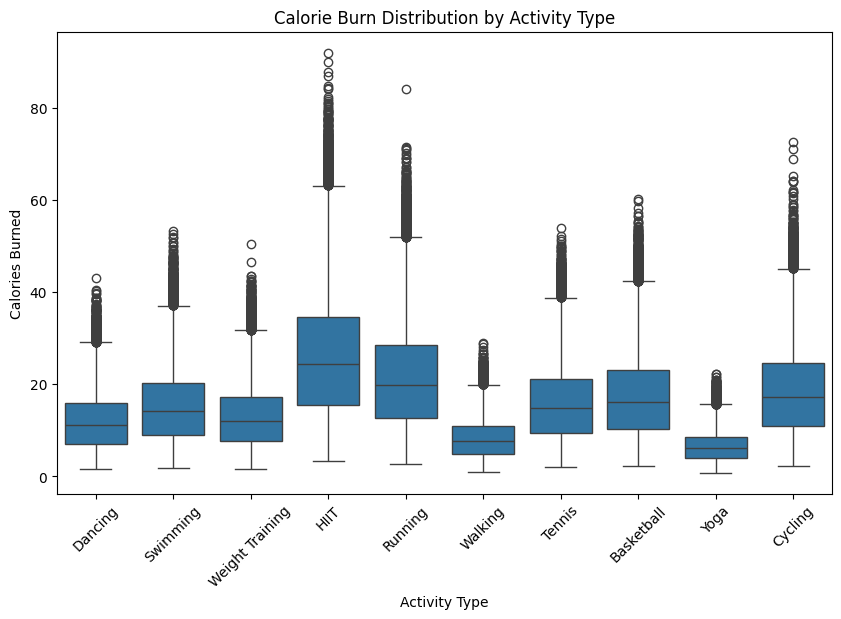

In [35]:
# Step 3. "SciPy Application:
# Apply statistical testing to understand if there’s a significant difference in the number of calories burned across different workout types. You can use ANOVA (scipy.stats.f_oneway) to test if the calorie burn differs significantly between various workout categories (e.g., yoga, running, HIIT)."

# Testing differences of calories burned among activity types with ANOVA:

from scipy.stats import f_oneway
groups = [df[df['activity_type'] == category]['calories_burned'].dropna() 
          for category in df['activity_type'].unique()]

# Execute ANOVA
f_stat, p_val = f_oneway(*groups)

print(f"ANOVA F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_val:.4f}")

# Visual Check (Box Plot)
plt.figure(figsize=(10, 6))
sns.boxplot(x='activity_type', y='calories_burned', data=df)
plt.title(f'Calorie Burn Distribution by {'activity_type'.replace("_", " ").title()}')
plt.xticks(rotation=45)
plt.ylabel('Calories Burned')
plt.xlabel('Activity Type')
plt.show()

In [36]:
# The p-value is less than 0.05, so there is a significant difference. At least one activity type burns significantly more or fewer calories than the others. The boxplot shows this difference visually. It appears from the boxplot that that the calories burned differs among all the activity types, and substantially among several of them.

# "Linear regression (scipy.stats.linregress) could be used to predict future progress based on past data, such as predicting how many steps or calories a user will burn in the next week."
# To perform this task, I will create a function which I can call by participant_id to predict the next week's steps or calories. 

from scipy.stats import linregress

def predict_weekly_total(df, participant_id, target_col='calories_burned'):
    """
    Predicts the CUMULATIVE total (sum) of a metric for the next 7 days.
    """
    # 1. Filter and sort user data
    user_data = df[df['participant_id'] == participant_id].copy()
    user_data['date'] = pd.to_datetime(user_data['date'])
    user_data = user_data.sort_values('date')

    if len(user_data) < 2:
        return f"Insufficient data for Participant {participant_id}"

    # 2. Prepare X (days) and Y (metric)
    start_date = user_data['date'].min()
    user_data['days_since_start'] = (user_data['date'] - start_date).dt.days
    
    x = user_data['days_since_start']
    y = user_data[target_col]

    # 3. Fit Linear Regression
    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    # 4. Predict the next 7 individual days
    last_day = x.max()
    next_week_days = np.array([last_day + i for i in range(1, 8)])
    
    # Calculate y = mx + b for each day
    daily_predictions = (slope * next_week_days) + intercept
    
    # Ensure no negative values (can't burn negative calories)
    daily_predictions = np.maximum(0, daily_predictions)

    # 5. Sum the predictions for the weekly total
    weekly_total = round(np.sum(daily_predictions))

    return {
        'participant_id': participant_id,
        'metric': target_col,
        'predicted_weekly_total': round(weekly_total, 2),
        'daily_average_trend': round(np.mean(daily_predictions), 2),
        'is_increasing': slope > 0
    }

# Predicting total Calories for the next 7 days for a given user (user 101):
uid = 101
cal_prediction = predict_weekly_total(df, uid, target_col='calories_burned')
print(f"Predicted Calories next week for user {uid}: {cal_prediction['predicted_weekly_total']}")

# Predict total Steps for the next 7 days for the same user:
steps_prediction = predict_weekly_total(df, uid, target_col='daily_steps')
print(f"Predicted Steps next week for user {uid}: {steps_prediction['predicted_weekly_total']}")

Predicted Calories next week for user 101: 138
Predicted Steps next week for user 101: 48465


--- INDIVIDUAL ACTIVITY RESULTS (T-TESTS) ---
  Primary Activity  Avg Weight Loss (kg)  T-Test P-Value Significant?
6  Weight Training                  0.37        0.064813           No
9          Dancing                  0.08        0.648994           No
2          Walking                  0.07        0.710645           No
4             Yoga                 -0.01        0.948595           No
5       Basketball                 -0.03        0.863287           No
1          Cycling                 -0.06        0.776551           No
3           Tennis                 -0.07        0.714042           No
7         Swimming                 -0.09        0.659757           No
0             HIIT                 -0.14        0.460938           No
8          Running                 -0.14        0.476096           No

--- GLOBAL COMPARISON RESULTS (ANOVA) ---
ANOVA F-Statistic: 0.6242
ANOVA P-Value: 0.7774
Result: No significant difference in weight loss across different activities.


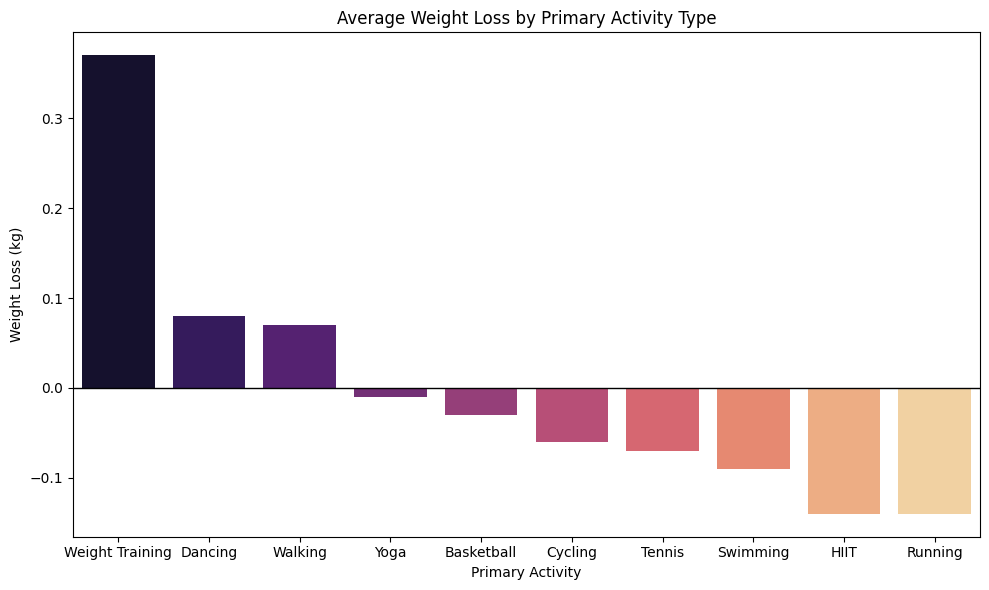

In [37]:
# "Use hypothesis testing to determine if specific workouts lead to significant changes in fitness goals (e.g., “Does strength training lead to significant weight loss?”). This could involve performing paired t-tests (scipy.stats.ttest_rel) to compare data before and after a user completes a particular workout regime."
# For this purpose, I will perform a longitudinal analysis of weight loss over time for different groups. For each participant, I will calculate the difference in weight between the first and last day as well as their most common activity. Then I will do a paired t-test to examine whether groups that primarily did each activity lost a statistically significant amount of weight.
# Next I will perform an ANOVA test to examine whether the amount of weight lost varied among groups to a statistically significant degree.


from scipy.stats import ttest_rel, f_oneway

# 1. Prepare the Longitudinal Data
# Ensuring the data is sorted by participant and date for accurate first/last tracking

df = df.sort_values(['participant_id', 'date'])

user_summary = []

for pid, group in df.groupby('participant_id'):
    if len(group) >= 2:
        start_w = group['weight_kg'].iloc[0]
        end_w = group['weight_kg'].iloc[-1]
        
        # Setting weight_loss variable such that positive result = Weight Loss (e.g., 90 - 85 = 5kg loss)
        weight_loss = start_w - end_w 
        
        user_summary.append({
            'participant_id': pid,
            'start_weight': start_w,
            'end_weight': end_w,
            'weight_loss': weight_loss,
            'primary_activity': group['activity_type'].mode()[0]
        })

summary_df = pd.DataFrame(user_summary)

# 2. Individual Group Testing (Paired T-Tests)
test_results = []
activity_groups = [] # To store weight loss arrays for ANOVA

unique_activities = summary_df['primary_activity'].unique()

for activity in unique_activities:
    subset = summary_df[summary_df['primary_activity'] == activity]
    
    # Store the weight loss values for the ANOVA later
    activity_groups.append(subset['weight_loss'])
    
    # T-Test: Did this specific group lose weight significantly?
    t_stat, p_val = ttest_rel(subset['start_weight'], subset['end_weight'])
    
    test_results.append({
        'Primary Activity': activity,
        'Avg Weight Loss (kg)': round(subset['weight_loss'].mean(), 2),
        'T-Test P-Value': p_val,
        'Significant?': "Yes" if p_val < 0.05 else "No"
    })

# Create and print the T-Test Ranking Table
ranking_table = pd.DataFrame(test_results).sort_values('Avg Weight Loss (kg)', ascending=False)
print("--- INDIVIDUAL ACTIVITY RESULTS (T-TESTS) ---")
print(ranking_table)

# 3. Comparative Testing (ANOVA)
# Did the activity choice make a significant difference in outcomes?
f_stat, anova_p = f_oneway(*activity_groups)

print("\n--- GLOBAL COMPARISON RESULTS (ANOVA) ---")
print(f"ANOVA F-Statistic: {f_stat:.4f}")
print(f"ANOVA P-Value: {anova_p:.4f}")

if anova_p < 0.05:
    print("Result: Significant difference found among activity types.")
else:
    print("Result: No significant difference in weight loss across different activities.")

# 4. Visualization
plt.figure(figsize=(10, 6))
sns.barplot(
    data=ranking_table, 
    x='Primary Activity', 
    y='Avg Weight Loss (kg)', 
    hue='Primary Activity', 
    palette='magma', 
    legend=False
)

plt.title('Average Weight Loss by Primary Activity Type')
plt.ylabel('Weight Loss (kg)')
plt.axhline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

In [38]:
# Conclusion: Some primary activity types generally led to weight loss, while some led to weight gain. The ANOVA test showed a statistically significant difference in weight changes among primary activity types. Only walking and tennis showed statistically significant weight changes (walking leading to weight loss, and tennis leading to weight gain.)

# Step 4. "Analyze and Visualize Data:

# Weekly Progress:

# Use Pandas to calculate total calories burned, steps taken, or workouts completed per week.
# Line plots for steps and calories burned over time."

# I will create a dataset that groups by participan and by week and shows the features to be calculated as columns.

# Convert date column to datetime format
df['date'] = pd.to_datetime(df['date'])

# Grouping by participant with the week starting on Sunday
# 'W-SUN' anchors the bin to end on Sunday, effectively grouping Sun-Sat
weekly_summary = df.groupby(['participant_id', pd.Grouper(key='date', freq='W-SUN')]).agg(
    total_calories=('calories_burned', 'sum'),
    total_steps=('daily_steps', 'sum'),
    workouts_count=('activity_type', 'count')
    ).reset_index()

# Rename to 'week_starting' and shift the label back 6 days to show the Sunday date
weekly_summary['week_starting'] = weekly_summary['date'] - pd.Timedelta(days=6)

# Drop the original 'date' column and reorder
weekly_summary = weekly_summary[['participant_id', 'week_starting', 'total_calories', 'total_steps', 'workouts_count']]

# Filter weekly_summary to include only full weeks:

# 1. Identify the latest date in your raw data
max_date = df['date'].max()

# 2. Filter out any week that ends after the max_date of the dataset
# We only keep weeks where the 'week_starting' + 6 days is <= our data's limit
complete_weeks = weekly_summary[weekly_summary['week_starting'] + pd.Timedelta(days=6) <= max_date]

complete_weeks.head()

,participant_id,week_starting,total_calories,total_steps,workouts_count
0,1,2024-01-01,19.5,33730,4
1,1,2024-01-08,44.8,30997,4
2,1,2024-01-15,76.1,47656,5
3,1,2024-01-22,28.0,24306,3
4,1,2024-01-29,61.5,52720,6


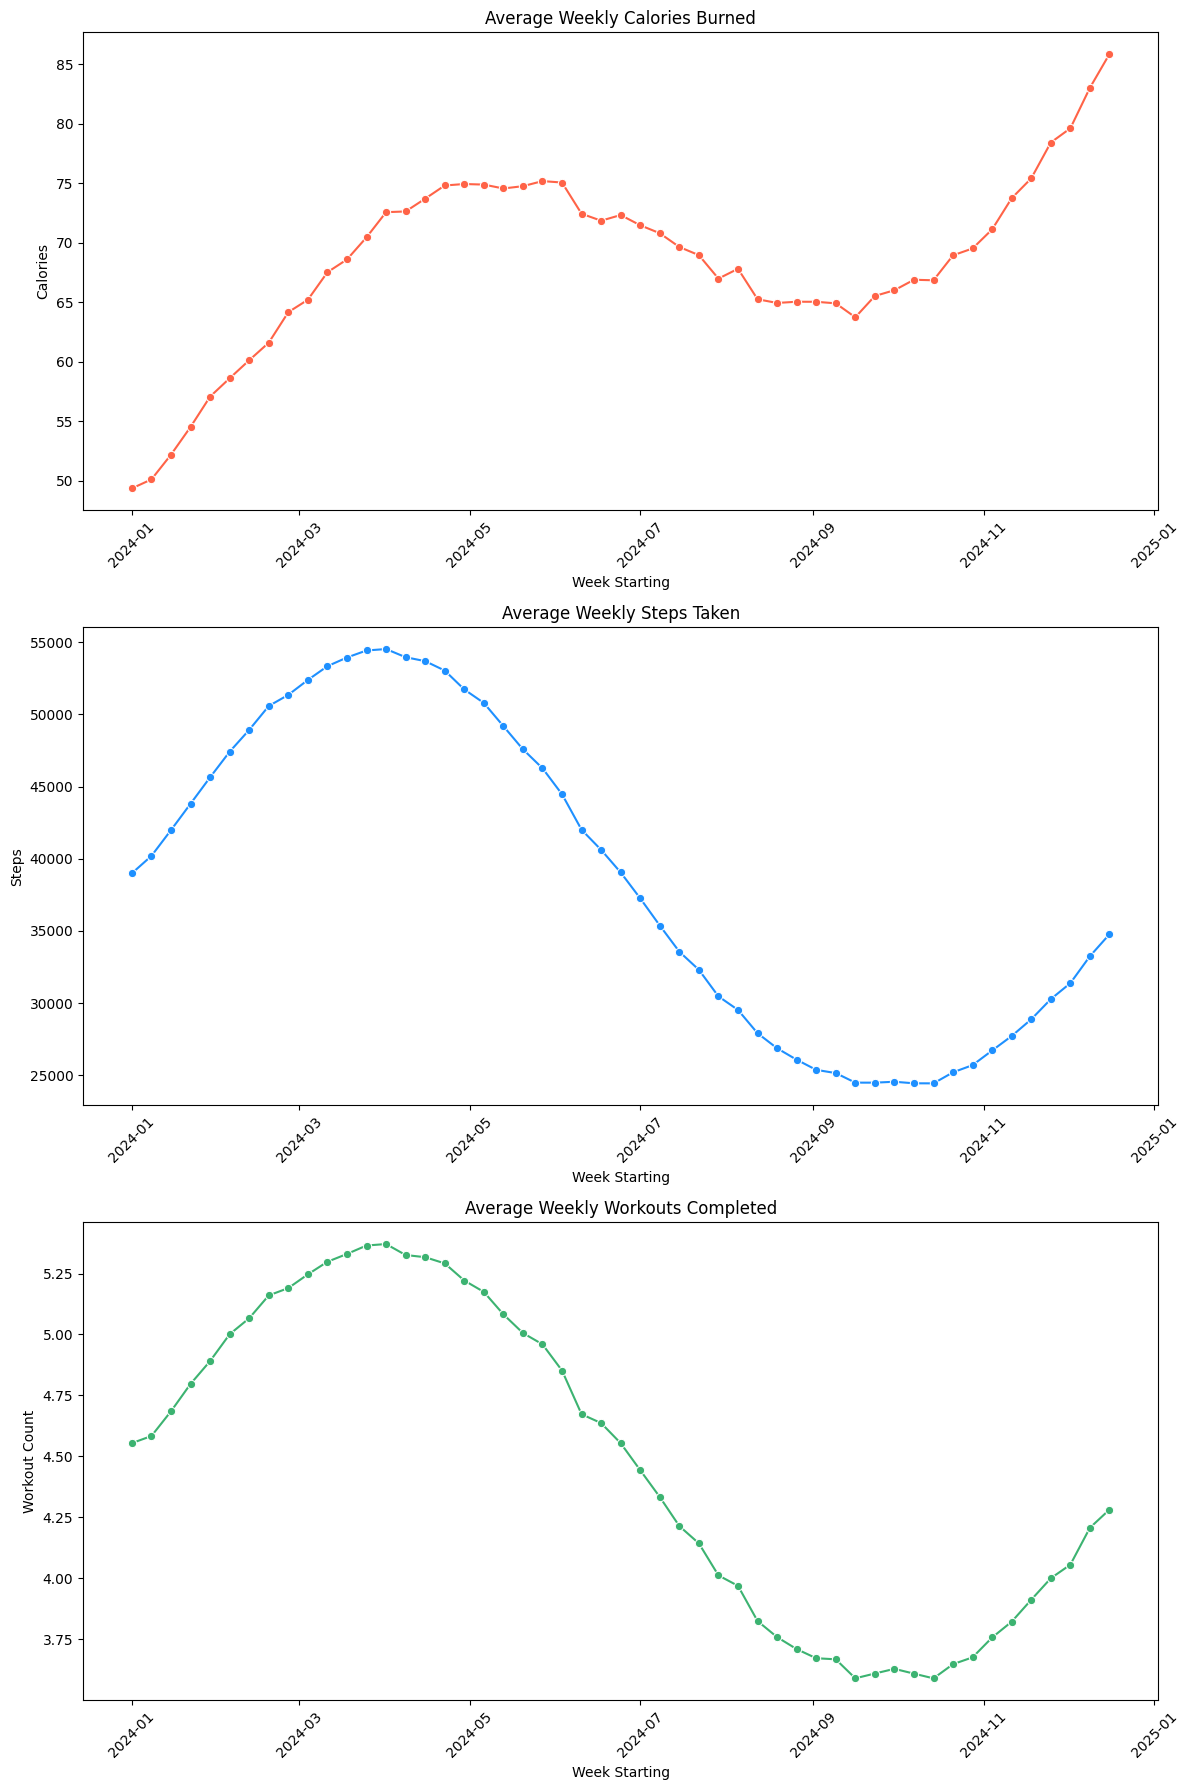

In [39]:
# Now I will visualize trends in total calories burned, steps taken, and workouts completed per week over time, on average across all users.


# 1. Ensure we are using the 'complete_weeks' filtered data from the previous step
overall_trends = complete_weeks.groupby('week_starting').agg(
    avg_calories=('total_calories', 'mean'),
    avg_steps=('total_steps', 'mean'),
    avg_workouts=('workouts_count', 'mean')
).reset_index()

# 2. Setup the visualization (sharex=False allows individual x-labels)
fig, axes = plt.subplots(3, 1, figsize=(12, 18), sharex=False)

# Define the metrics and colors for a loop to keep code DRY (Don't Repeat Yourself)
metrics = [
    ('avg_calories', 'Calories', 'tomato', 'Average Weekly Calories Burned'),
    ('avg_steps', 'Steps', 'dodgerblue', 'Average Weekly Steps Taken'),
    ('avg_workouts', 'Workout Count', 'mediumseagreen', 'Average Weekly Workouts Completed')
]

for i, (col, ylabel, color, title) in enumerate(metrics):
    sns.lineplot(
        data=overall_trends, 
        x='week_starting', 
        y=col, 
        ax=axes[i], 
        color=color, 
        marker='o'
    )
    axes[i].set_title(title)
    axes[i].set_ylabel(ylabel)
    axes[i].set_xlabel('Week Starting') # Explicitly set for every plot
    
    # Rotate labels on every axis specifically
    plt.setp(axes[i].get_xticklabels(), rotation=45)

# 3. Final spacing adjustment
plt.tight_layout()
plt.show()

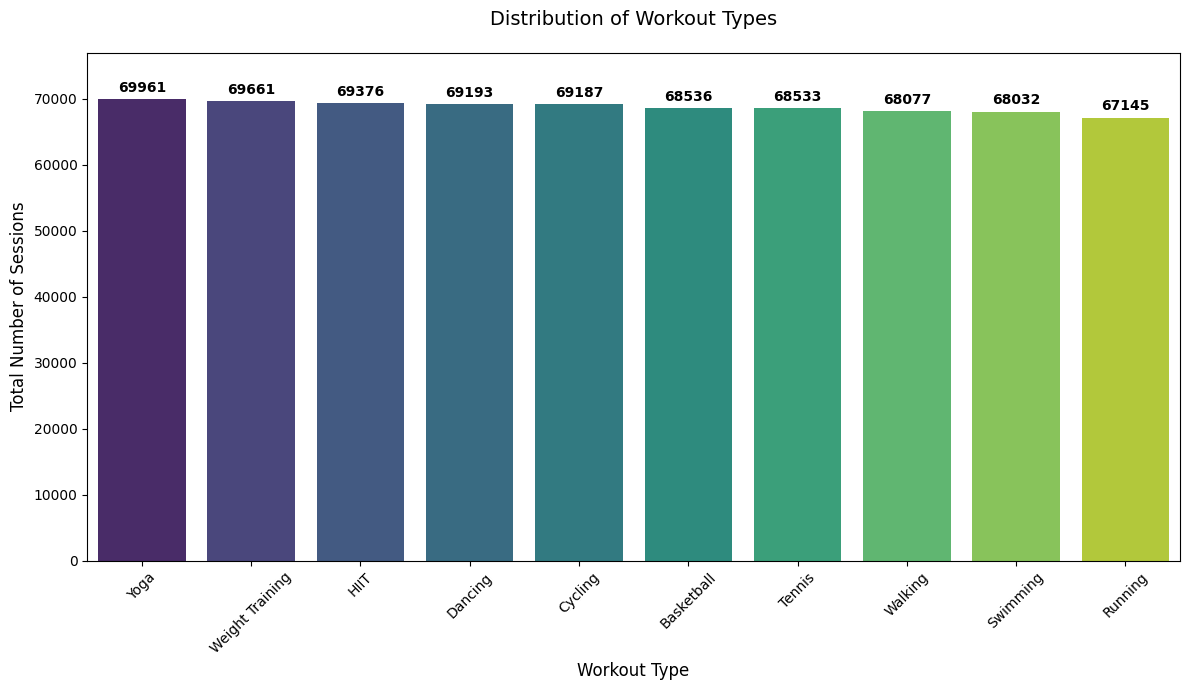

In [40]:
# "Bar plots showing the frequency of workout types."

# 1. Prepare the frequency data
workout_counts = df['activity_type'].value_counts().reset_index()
workout_counts.columns = ['activity_type', 'count']

# 2. Create the Bar Plot
plt.figure(figsize=(12, 7))

# Assign the plot to an 'ax' object
ax = sns.barplot(
    data=workout_counts, 
    x='activity_type', 
    y='count', 
    hue='activity_type', 
    palette='viridis', 
    legend=False
)

# 3. Loop through every container to label every bar
# Since hue is used, each bar is in its own container
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10, fontweight='bold')

# 4. Formatting
plt.title('Distribution of Workout Types', fontsize=14, pad=20)
plt.xlabel('Workout Type', fontsize=12)
plt.ylabel('Total Number of Sessions', fontsize=12)
plt.xticks(rotation=45)

# Add 10% headroom to the Y-axis for the labels
plt.ylim(0, workout_counts['count'].max() * 1.1)

plt.tight_layout()
plt.show()

In [ ]:
# Conclusion: The distribution of workout types is very similar among types.